ติดตั้ง Pyspark
---

In [ ]:
# ติดตั้ง PySpark (เวอร์ชันล่าสุด)
!pip install pyspark

# ติดตั้ง Java ถ้าจำเป็น (Colab มี Java 8+ อยู่แล้ว แต่เพื่อความแน่นอน)
!apt-get update -qq > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# ตั้งค่า JAVA_HOME
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
from pyspark.sql import SparkSession

# สร้าง SparkSession
spark = SparkSession.builder \
    .appName("Healthcare Stroke Data") \
    .config("spark.sql.repl.eagerEval.enabled", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# ตรวจสอบเวอร์ชัน
print("Spark Version:", spark.version)

Spark Version: 3.5.1


โหลดข้อมูล
---

In [ ]:
# URL ของ CSV
url = "https://raw.githubusercontent.com/kimurasaika/car_price_prediction/refs/heads/main/healthcare-dataset-stroke-data%20(1).csv"
local_path = "/tmp/healthcare-dataset-stroke-data.csv"

# ดาวน์โหลดไฟล์ CSV จาก URL
import requests
response = requests.get(url)
with open(local_path, "wb") as f:
    f.write(response.content)

# อ่าน CSV จากไฟล์ที่ดาวน์โหลด
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("encoding", "UTF-8") \
    .csv(local_path)

# Cache DataFrame ถ้าจะใช้บ่อย (optional สำหรับ dataset เล็ก)
df.cache()

# ตรวจสอบ schema
df.printSchema()

# แสดงจำนวน rows และ columns
print("จำนวน rows:", df.count())
print("คอลัมน์ทั้งหมด:", df.columns)

# แสดงตัวอย่าง 5 แถวแรก
df.show(5, truncate=False)

root
 |-- id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- hypertension: integer (nullable = true)
 |-- heart_disease: integer (nullable = true)
 |-- ever_married: string (nullable = true)
 |-- work_type: string (nullable = true)
 |-- Residence_type: string (nullable = true)
 |-- avg_glucose_level: double (nullable = true)
 |-- bmi: string (nullable = true)
 |-- smoking_status: string (nullable = true)
 |-- stroke: integer (nullable = true)

จำนวน rows: 5110
คอลัมน์ทั้งหมด: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
+-----+------+----+------------+-------------+------------+-------------+--------------+-----------------+----+---------------+------+
|id   |gender|age |hypertension|heart_disease|ever_married|work_type    |Residence_type|avg_glucose_level|bmi |smoking_status |stroke|
+-----+------+----+------------+

In [ ]:
df.describe(["bmi", "age", "avg_glucose_level"]).show()
df.select("gender").distinct().show()

+-------+------------------+------------------+------------------+
|summary|               bmi|               age| avg_glucose_level|
+-------+------------------+------------------+------------------+
|  count|              5110|              5110|              5110|
|   mean|28.893236911794673|43.226614481409015|106.14767710371804|
| stddev|  7.85406672968016| 22.61264672311348| 45.28356015058193|
|    min|              10.3|              0.08|             55.12|
|    max|               N/A|              82.0|            271.74|
+-------+------------------+------------------+------------------+

+------+
|gender|
+------+
|Female|
| Other|
|  Male|
+------+



In [ ]:
print("จำนวนแถว:", df.count())
df.printSchema()
df.show(5, truncate=False)

จำนวนแถว: 5110
root
 |-- id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- hypertension: integer (nullable = true)
 |-- heart_disease: integer (nullable = true)
 |-- ever_married: string (nullable = true)
 |-- work_type: string (nullable = true)
 |-- Residence_type: string (nullable = true)
 |-- avg_glucose_level: double (nullable = true)
 |-- bmi: string (nullable = true)
 |-- smoking_status: string (nullable = true)
 |-- stroke: integer (nullable = true)

+-----+------+----+------------+-------------+------------+-------------+--------------+-----------------+----+---------------+------+
|id   |gender|age |hypertension|heart_disease|ever_married|work_type    |Residence_type|avg_glucose_level|bmi |smoking_status |stroke|
+-----+------+----+------------+-------------+------------+-------------+--------------+-----------------+----+---------------+------+
|9046 |Male  |67.0|0           |1            |Yes         |Private      |Ur

In [ ]:
from pyspark.sql.types import DoubleType
from pyspark.sql import functions as F

# แปลงคอลัมน์ bmi เป็น double และแทนค่า "N/A" ด้วย None
df = df.filter(F.col("gender") != "Other")
print("ลบแถว gender = 'Other' เรียบร้อยแล้ว")
df.select("gender").distinct().show()

df = df.withColumn(
    "bmi",
    F.when((F.col("bmi") == "N/A") | (F.col("bmi") == "") | (F.col("bmi").isNull()), None)
     .otherwise(F.col("bmi")))
df = df.withColumn("bmi", F.col("bmi").cast(DoubleType()))

# แสดงจำนวน N/A ก่อนเติม
print("จำนวน N/A:")
df.select(F.count(F.when(F.col("bmi").isNull(), 1)).alias("missing_bmi")).show()

# คำนวณ median แล้วเติมค่า N/A ด้วย median
median_bmi = df.approxQuantile("bmi", [0.5], 0.01)[0]
print(f"Median BMI = {median_bmi:.2f}")
print(f"")

df = df.withColumn(
    "bmi",
    F.when(F.col("bmi").isNull(), F.lit(median_bmi))
     .otherwise(F.col("bmi")))

# ตรวจสอบหลังเติมค่า (ไม่มี N/A แล้ว)
print("Missing BMI หลังเติม:")
df.select(F.count(F.when(F.col("bmi").isNull(), 1)).alias("missing_bmi_after")).show()

# แสดงค่าทางสถิติของ bmi ก่อนตัด outlier
print("ค่า BMI ก่อนตัด outlier:")

df.describe(["bmi"]).show()

# คำนวณ IQR แล้วตัด outlier
q1, q3 = df.approxQuantile("bmi", [0.25, 0.75], 0.01)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"ขอบล่าง={lower:.2f}, ขอบบน={upper:.2f}")

# ลบแถวที่ outlier
count_before = df.count()
df = df.filter((F.col("bmi") >= lower) & (F.col("bmi") <= upper))
count_after = df.count()

print(f"\nลบแถว outlier เรียบร้อยแล้ว")
print(f"จำนวนแถวก่อนลบ: {count_before}")
print(f"จำนวนแถวหลังลบ: {count_after}")
print(f"จำนวนแถวที่ถูกลบออก: {count_before - count_after}")
print(f"")

# เซ็ตค่า outlier เป็น None (null)
df = df.withColumn(
    "bmi",
    F.when((F.col("bmi") < lower) | (F.col("bmi") > upper), None)
     .otherwise(F.col("bmi")))

# แสดงผลหลังตัด outlier
print("ค่า BMI หลังตัด outlier:")
df.describe(["bmi"]).show()

# ตรวจสอบจำนวนค่า missing หลังตัด (จะเพิ่มขึ้น เพราะ outlier ถูกเซ็ตเป็น None)
print("Missing BMI หลังตัด outlier:")
df.select(F.count(F.when(F.col("bmi").isNull(), 1)).alias("missing_bmi_final")).show()

ลบแถว gender = 'Other' เรียบร้อยแล้ว
+------+
|gender|
+------+
|Female|
|  Male|
+------+

จำนวน N/A:
+-----------+
|missing_bmi|
+-----------+
|        201|
+-----------+

Median BMI = 28.00

Missing BMI หลังเติม:
+-----------------+
|missing_bmi_after|
+-----------------+
|                0|
+-----------------+

ค่า BMI ก่อนตัด outlier:
+-------+-----------------+
|summary|              bmi|
+-------+-----------------+
|  count|             5109|
|   mean|28.85936582501467|
| stddev|7.700199637717419|
|    min|             10.3|
|    max|             97.6|
+-------+-----------------+

Q1=23.60, Q3=32.60, IQR=9.00
ขอบล่าง=10.10, ขอบบน=46.10

ลบแถว outlier เรียบร้อยแล้ว
จำนวนแถวก่อนลบ: 5109
จำนวนแถวหลังลบ: 4982
จำนวนแถวที่ถูกลบออก: 127

ค่า BMI หลังตัด outlier:
+-------+------------------+
|summary|               bmi|
+-------+------------------+
|  count|              4982|
|   mean|28.238779606583726|
| stddev| 6.625538547769833|
|    min|              10.3|
|    max|              4

In [ ]:
# check value after ตัดค่า outlier
cols_to_check = ["gender", "stroke"]
for col in cols_to_check:
    print(f"\nDistribution ของคอลัมน์: {col}")
    df.groupBy(col).count().orderBy(F.desc("count")).show(truncate=False)


Distribution ของคอลัมน์: gender
+------+-----+
|gender|count|
+------+-----+
|Female|2895 |
|Male  |2087 |
+------+-----+


Distribution ของคอลัมน์: stroke
+------+-----+
|stroke|count|
+------+-----+
|0     |4736 |
|1     |246  |
+------+-----+



dummy
---

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType # Import ArrayType

# ระบุคอลัมน์ categorical ที่ต้อง encode
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

# ตรวจสอบว่าคอลัมน์เหล่านี้มีอยู่จริง
print("คอลัมน์ที่มีอยู่ใน DataFrame:")
print(df.columns)

# เตรียมขั้นตอนการแปลงข้อความ -> ตัวเลข -> one-hot
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical_cols]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe", handleInvalid="keep", dropLast=True) for c in categorical_cols]
pipeline = Pipeline(stages=indexers + encoders)


# แปลงข้อมูล
df_encoded = pipeline.fit(df).transform(df)

print("ทำ One-Hot Encoding เสร็จแล้ว")
df_encoded.select("gender", "gender_idx", "gender_ohe").show(5, truncate=False)

# แปลง vector columns → แยกออกเป็นคอลัมน์ scalar สำหรับ CSV
vector_cols = [c for c in df_encoded.columns if c.endswith("_ohe")]

for c in vector_cols:
    # Convert vector to array, handling potential None values
    df_encoded = df_encoded.withColumn(c, vector_to_array(F.col(c)))

for c in vector_cols:
    # Check if the column is an array type before processing
    if isinstance(df_encoded.schema[c].dataType, ArrayType):
        # Get the size of the array (number of elements)
        first_row = df_encoded.select(c).filter(F.col(c).isNotNull()).first()
        if first_row:
            n = len(first_row[0])
            for i in range(n):
                df_encoded = df_encoded.withColumn(f"{c}_{i}", F.col(c)[i])
        df_encoded = df_encoded.drop(c)  # Drop the original vector column


print("แยกคอลัมน์ dummy เสร็จสมบูรณ์")

# ตรวจสอบผลลัพธ์
print("คอลัมน์ทั้งหมดหลัง encode:")
print(df_encoded.columns)

# แสดงตัวอย่าง 5 แถวแรก
df_encoded.show(5, truncate=False)

คอลัมน์ที่มีอยู่ใน DataFrame:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
ทำ One-Hot Encoding เสร็จแล้ว
+------+----------+-------------+
|gender|gender_idx|gender_ohe   |
+------+----------+-------------+
|Male  |1.0       |(3,[1],[1.0])|
|Female|0.0       |(3,[0],[1.0])|
|Male  |1.0       |(3,[1],[1.0])|
|Female|0.0       |(3,[0],[1.0])|
|Female|0.0       |(3,[0],[1.0])|
+------+----------+-------------+
only showing top 5 rows

แยกคอลัมน์ dummy เสร็จสมบูรณ์
คอลัมน์ทั้งหมดหลัง encode:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'gender_idx', 'ever_married_idx', 'work_type_idx', 'Residence_type_idx', 'smoking_status_idx', 'gender_ohe_0', 'gender_ohe_1', 'gender_ohe_2', 'ever_married_ohe_0', 'ever_married_ohe_1', 'ever_married_ohe_2', 'work_type_ohe_0', 'wor

In [ ]:
# ตรวจสอบคอลัมน์ที่พร้อมใช้ใน Machine Learning
from pyspark.sql.types import NumericType

# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (numeric)
numeric_cols = [field.name for field in df_encoded.schema.fields if isinstance(field.dataType, NumericType)]

# Drop gender_idx column
cols_to_drop = ['gender_idx','work_type_idx','Residence_type_idx','smoking_status_idx', 'id','ever_married_idx']
for col in cols_to_drop:
  if col in numeric_cols:
    numeric_cols.remove(col)

print("คอลัมน์เชิงตัวเลขทั้งหมดที่พร้อมใช้ใน ML:")
print(numeric_cols)
print(f"\nจำนวนคอลัมน์ที่ใช้เป็น features ทั้งหมด: {len(numeric_cols)}")

# แสดงตัวอย่าง 5 แถวแรกของเฉพาะ numeric columns
print("\nตัวอย่างข้อมูล (เฉพาะ feature columns):")
df_encoded.select(numeric_cols).show(5, truncate=False)

คอลัมน์เชิงตัวเลขทั้งหมดที่พร้อมใช้ใน ML:
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_ohe_0', 'gender_ohe_1', 'gender_ohe_2', 'ever_married_ohe_0', 'ever_married_ohe_1', 'ever_married_ohe_2', 'work_type_ohe_0', 'work_type_ohe_1', 'work_type_ohe_2', 'work_type_ohe_3', 'work_type_ohe_4', 'work_type_ohe_5', 'Residence_type_ohe_0', 'Residence_type_ohe_1', 'Residence_type_ohe_2', 'smoking_status_ohe_0', 'smoking_status_ohe_1', 'smoking_status_ohe_2', 'smoking_status_ohe_3', 'smoking_status_ohe_4']

จำนวนคอลัมน์ที่ใช้เป็น features ทั้งหมด: 26

ตัวอย่างข้อมูล (เฉพาะ feature columns):
+----+------------+-------------+-----------------+----+------+------------+------------+------------+------------------+------------------+------------------+---------------+---------------+---------------+---------------+---------------+---------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------

change to pandas dataframe

In [ ]:
import pandas as pd

# Convert the selected Spark DataFrame columns to a pandas DataFrame
df_pandas = df_encoded.select(numeric_cols).toPandas()
# df_pandas = df.toPandas()

print("Converted Spark DataFrame to pandas DataFrame.")
print("Shape of pandas DataFrame:", df_pandas.shape)
display(df_pandas.head())

Converted Spark DataFrame to pandas DataFrame.
Shape of pandas DataFrame: (4982, 26)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_ohe_0,gender_ohe_1,gender_ohe_2,ever_married_ohe_0,...,work_type_ohe_4,work_type_ohe_5,Residence_type_ohe_0,Residence_type_ohe_1,Residence_type_ohe_2,smoking_status_ohe_0,smoking_status_ohe_1,smoking_status_ohe_2,smoking_status_ohe_3,smoking_status_ohe_4
0,67.0,0,1,228.69,36.6,1,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,61.0,0,0,202.21,28.0,1,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,80.0,0,1,105.92,32.5,1,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,49.0,0,0,171.23,34.4,1,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,79.0,1,0,174.12,24.0,1,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'Correlation Heatmap Pearson')

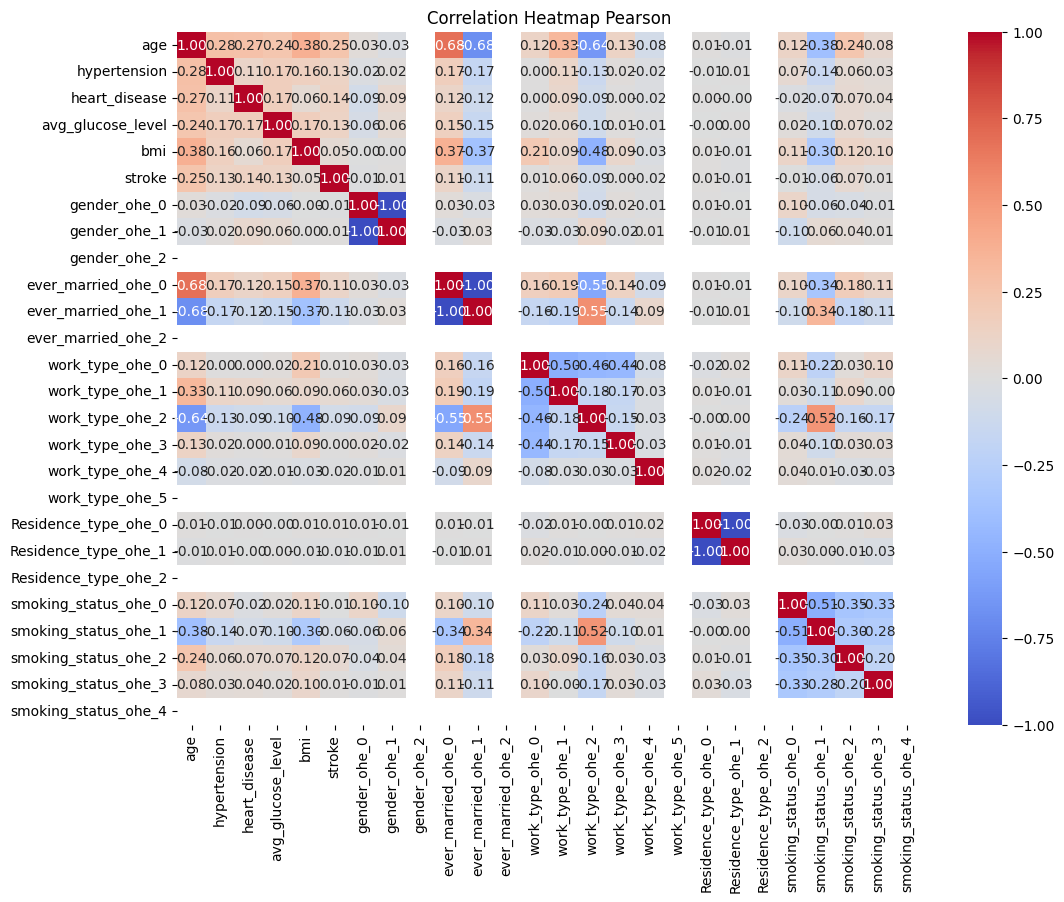

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

nu_df = df_pandas.select_dtypes(include = [np.number])
plt.figure(figsize = (12,9))
corr = nu_df.corr(method = 'pearson')
sns.heatmap(corr , fmt = '.2f' , annot = True , cmap = 'coolwarm' )
plt.title('Correlation Heatmap Pearson')

In [ ]:
from sklearn.utils import resample
import pandas as pd

# Assuming df_pandas is your pandas DataFrame after preprocessing
df_minority = df_pandas[df_pandas['stroke'] == 1]
df_majority = df_pandas[df_pandas['stroke'] == 0]

# Upsample minority class
df_minority_upsampled = resample(df_minority,
                                  replace=True,     # Resampling with replacement
                                  n_samples=len(df_majority),    # Match number of majority class
                                  random_state=42)  # for reproducibility

# Combine majority class with upsampled minority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Display new class counts
print("Class counts after upsampling:")
print(df_upsampled['stroke'].value_counts())

# Now use df_upsampled for further steps (e.g., splitting into X and y, training)
# For example, updating the X and y variables:
X = df_upsampled.drop('stroke', axis=1)
y = df_upsampled['stroke']

print("\nShape of upsampled X:", X.shape)
print("Shape of upsampled y:", y.shape)

Class counts after upsampling:
stroke
0    4736
1    4736
Name: count, dtype: int64

Shape of upsampled X: (9472, 25)
Shape of upsampled y: (9472,)


In [ ]:
# dropcol = ['stroke','gender_ohe_2','ever_married_ohe_2','Residence_type_ohe_2','smoking_status_ohe_4']
# X = df_upsampled.drop('stroke')
# y = df_upsampled["stroke"]

In [ ]:
from sklearn.metrics import accuracy_score , classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train_sc = scaler.transform(X_train)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)

In [ ]:
X_test_sc = scaler.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5,
           shuffle=True,
           random_state=1234)

In [ ]:
folds = kf.split(y_train)

In [ ]:
n_fold = 1
for train_index, val_index in folds:
    print("====\nIteration: ",n_fold)
    n_fold += 1
    print("train sample fract (class 1/0): ", y_train[train_index].value_counts()[1]/y_train[train_index].value_counts()[0])
    print("validate sample fract (class 1/0): ", y_train[val_index].value_counts()[1]/y_train[val_index].value_counts()[0])

====
Iteration:  1
train sample fract (class 1/0):  1.0149601063829787
validate sample fract (class 1/0):  0.9435897435897436
====
Iteration:  2
train sample fract (class 1/0):  0.999670075882547
validate sample fract (class 1/0):  1.0026420079260239
====
Iteration:  3
train sample fract (class 1/0):  0.9791054521710741
validate sample fract (class 1/0):  1.089655172413793
====
Iteration:  4
train sample fract (class 1/0):  0.9947351102336295
validate sample fract (class 1/0):  1.0226969292389854
====
Iteration:  5
train sample fract (class 1/0):  1.013284623048821
validate sample fract (class 1/0):  0.9498069498069498


StratifiedKFold

In [ ]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234) # With shuffle=True, random_state can now be set

In [ ]:
folds = skf.split(X=X_train_sc, y=y_train)

In [ ]:
n_fold = 1
for train_index, val_index in folds:
    print("====\nIteration: ",n_fold)
    n_fold += 1
    print("train sample ratio (class 1/0): ", y_train[train_index].value_counts()[1]/y_train[train_index].value_counts()[0])
    print("validate sample ratio (class 1/0): ", y_train[val_index].value_counts()[1]/y_train[val_index].value_counts()[0])

====
Iteration:  1
train sample ratio (class 1/0):  1.0003300330033003
validate sample ratio (class 1/0):  1.0
====
Iteration:  2
train sample ratio (class 1/0):  1.0003300330033003
validate sample ratio (class 1/0):  1.0
====
Iteration:  3
train sample ratio (class 1/0):  1.0006600660066007
validate sample ratio (class 1/0):  0.9986807387862797
====
Iteration:  4
train sample ratio (class 1/0):  1.0
validate sample ratio (class 1/0):  1.0013210039630118
====
Iteration:  5
train sample ratio (class 1/0):  1.0
validate sample ratio (class 1/0):  1.0013210039630118


Use skf to split fold

Get score from each fold

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42, criterion='gini',max_depth=None,min_samples_leaf=1,min_samples_split=10)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn import metrics
scores = cross_validate(estimator=clf,
                        X=X_train_sc,
                        y=y_train,
                        cv=skf,
                        scoring=['roc_auc','accuracy']
)
scores

{'fit_time': array([0.02166152, 0.02059984, 0.01799273, 0.01837897, 0.01737666]),
 'score_time': array([0.00576186, 0.00603533, 0.00435376, 0.00456309, 0.00526714]),
 'test_roc_auc': array([0.96614128, 0.97150013, 0.9688867 , 0.9649873 , 0.9679186 ]),
 'test_accuracy': array([0.96635884, 0.97097625, 0.96831683, 0.96435644, 0.9650165 ])}

In [ ]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(estimator=clf,
                           X=X_train_sc,
                           y=y_train,
                           cv=skf)
conf_mat = metrics.confusion_matrix(y_train, y_pred, labels=[1,0])

In [ ]:
tp, fn, fp, tn = conf_mat.ravel()
print("true positives(tp):", tp)
print("false negatives(fn):", fn)
print("false positives(fp):", fp)
print("true negatives(tn):", tn)

true positives(tp): 3789
false negatives(fn): 0
false positives(fp): 250
true negatives(tn): 3538


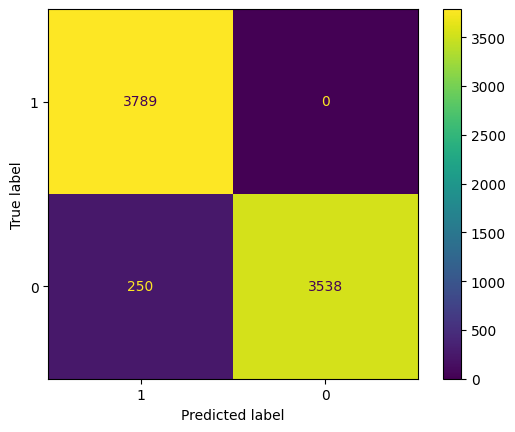

In [ ]:
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[1,0]).plot()

accuracy :  0.9751978891820581
f1-score :  0.975785677485832
recall :  1.0
precision :  0.9527162977867203
roc auc score :  0.975210970464135


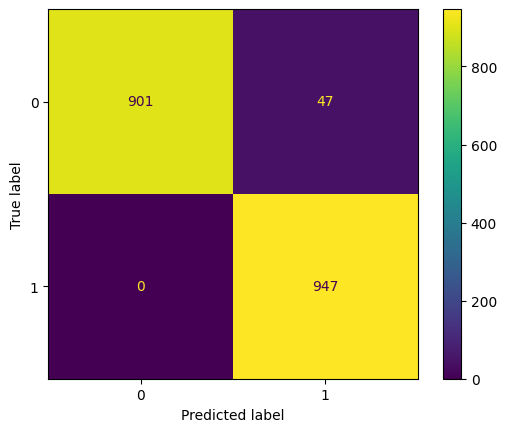

In [ ]:
clf = clf.fit(X_train_sc, y_train)
y_pred = clf.predict(X_test_sc)
print('accuracy : ',metrics.accuracy_score(y_test, y_pred))
print('f1-score : ',metrics.f1_score(y_test, y_pred))
print('recall : ',metrics.recall_score(y_test, y_pred))
print('precision : ',metrics.precision_score(y_test, y_pred))
print('roc auc score : ',metrics.roc_auc_score(y_test, y_pred))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Fine-tune Model with GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 9, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=clf,
                           param_grid=param_grid,
                           cv=skf,
                           scoring='roc_auc',
                           n_jobs=-1)
grid_search.fit(X_train_sc, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best ROC AUC score found: ", grid_search.best_score_)

best_clf = grid_search.best_estimator_

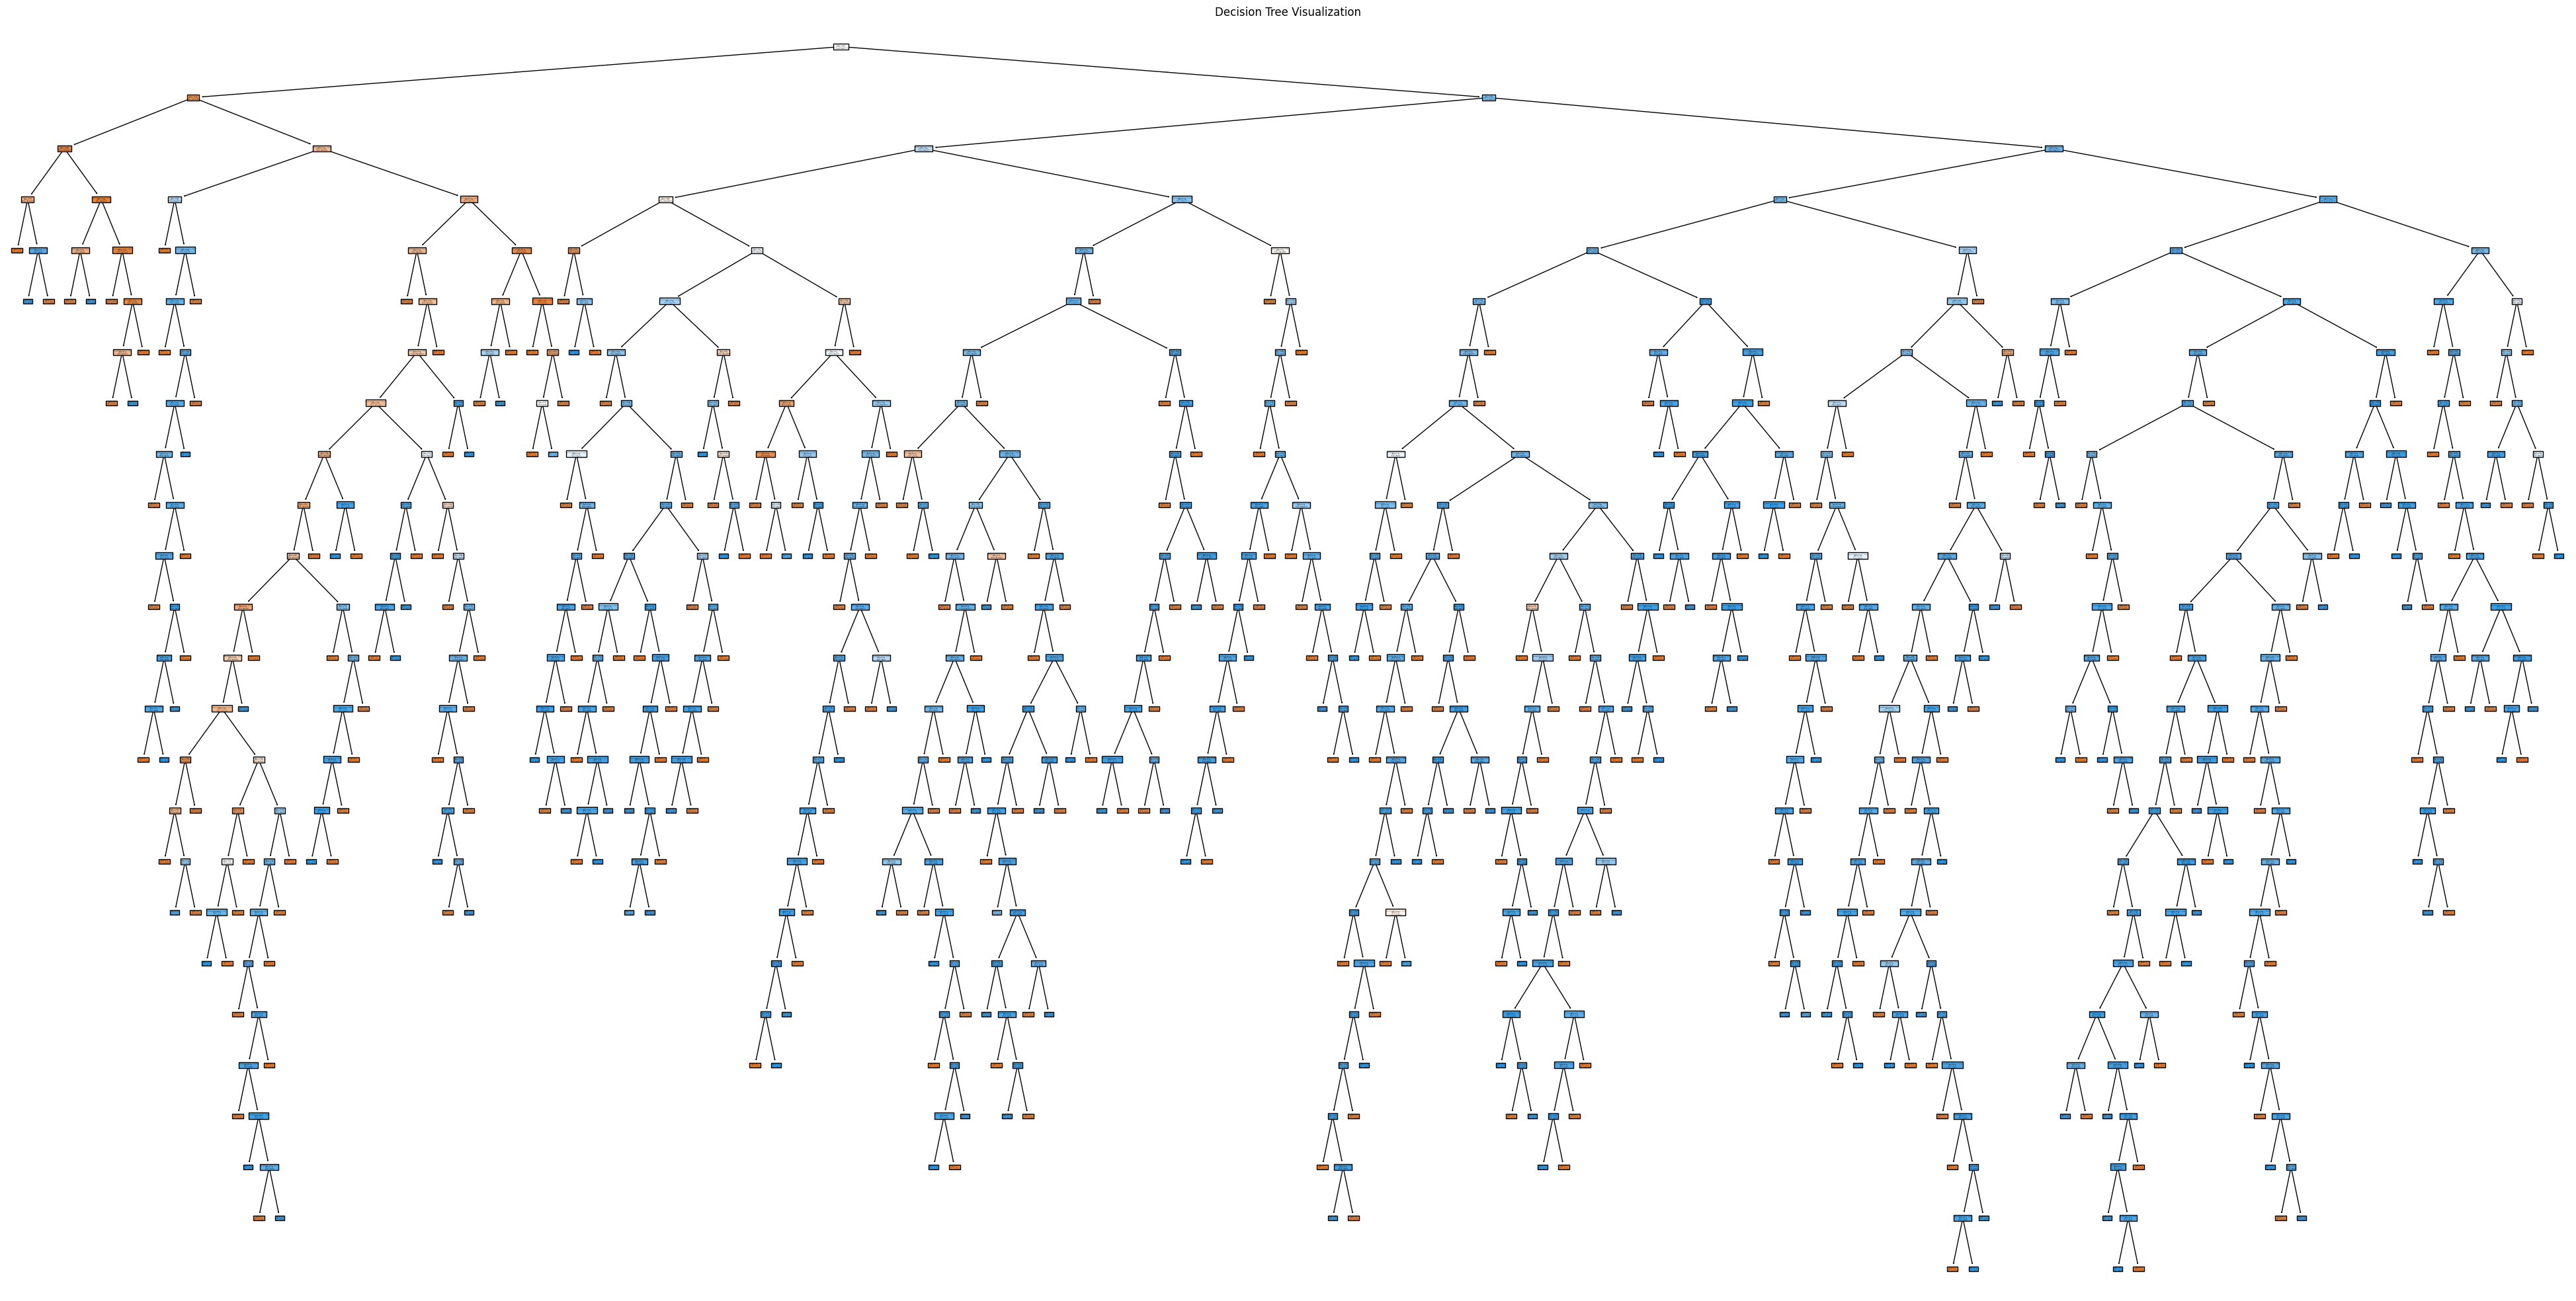

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(50, 25))
plot_tree(clf, feature_names=X.columns, class_names=['No Stroke', 'Stroke'], filled=True)
plt.title('Decision Tree Visualization')
plt.show()

Neural MLP

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=200, random_state=42)
# mlp = MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(100,50), learning_rate='constant', max_iter=200, random_state=42)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn import metrics
scores = cross_validate(estimator=mlp,
                        X=X_train_sc,
                        y=y_train,
                        cv=skf,
                        scoring=['roc_auc','accuracy']
)
scores

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

{'fit_time': array([ 8.16826534,  8.57141256,  7.11847496,  8.6287055 , 10.96853352]),
 'score_time': array([0.00947332, 0.00855565, 0.01671529, 0.01180744, 0.00898457]),
 'test_roc_auc': array([0.97703824, 0.97005033, 0.97269635, 0.97867049, 0.98039058]),
 'test_accuracy': array([0.95448549, 0.94920844, 0.95709571, 0.94983498, 0.95115512])}

In [ ]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(estimator=clf,
                           X=X_train_sc,
                           y=y_train,
                           cv=skf)
conf_mat = metrics.confusion_matrix(y_train, y_pred, labels=[1,0])

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [ ]:
tp, fn, fp, tn = conf_mat.ravel()
print("true positives(tp):", tp)
print("false negatives(fn):", fn)
print("false positives(fp):", fp)
print("true negatives(tn):", tn)

true positives(tp): 3683
false negatives(fn): 106
false positives(fp): 578
true negatives(tn): 3210


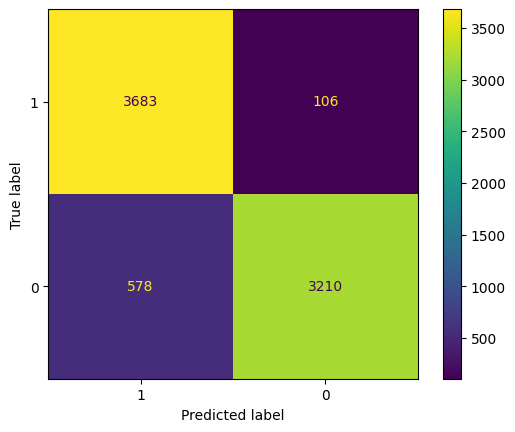

In [ ]:
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[1,0]).plot()

In [ ]:
metrics.roc_auc_score(y_train, y_pred)

np.float64(0.9097185818003151)

accuracy :  0.9709762532981531
f1-score :  0.9717804002052335
recall :  1.0
precision :  0.9451097804391217
roc auc score :  0.9709915611814346


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


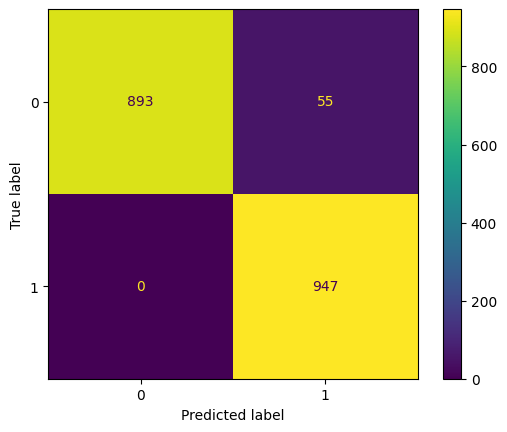

In [ ]:
mlp = mlp.fit(X_train_sc, y_train)
y_pred = mlp.predict(X_test_sc)

print('accuracy : ',metrics.accuracy_score(y_test, y_pred))
print('f1-score : ',metrics.f1_score(y_test, y_pred))
print('recall : ',metrics.recall_score(y_test, y_pred))
print('precision : ',metrics.precision_score(y_test, y_pred))
print('roc auc score : ',metrics.roc_auc_score(y_test, y_pred))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

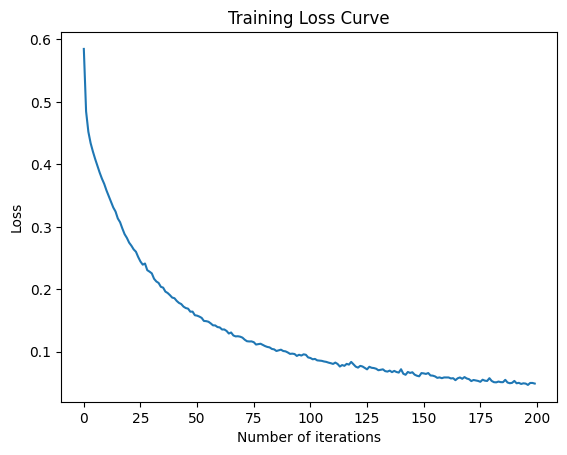

In [ ]:
import matplotlib.pyplot as plt

loss_values = mlp.loss_curve_
plt.plot(loss_values)
plt.xlabel('Number of iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
import pandas as pd

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [200]
}

clf = MLPClassifier( random_state=42)

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_sc, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best ROC AUC score found: ", grid_search.best_score_)

best_clf = grid_search.best_estimator_

y_pred = best_clf.predict(X_test_sc)
y_pred_proba = best_clf.predict_proba(X_test_sc)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Test ROC AUC score: ", test_roc_auc)
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

Best parameters found:  {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'max_iter': 200}
Best ROC AUC score found:  0.9810180119622863
Test ROC AUC score:  0.9888265853973687
Classification Report on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       948
           1       0.95      1.00      0.97       947

    accuracy                           0.97      1895
   macro avg       0.97      0.97      0.97      1895
weighted avg       0.97      0.97      0.97      1895



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
